# Basic EDA and Charts

In [ ]:
!pip install pandas numpy matplotlib seaborn

# Part 1: Basic EDA

In [2]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Loading the dataset
url = "https://raw.githubusercontent.com/pandas-dev/pandas/master/doc/data/titanic.csv"
df = pd.read_csv(url)

In [4]:
# Basic EDA
# Number of columns and rows
df.shape

(891, 12)

In [5]:
# Sample data
df.sample(7)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
226,227,1,2,"Mellors, Mr. William John",male,19.0,0,0,SW/PP 751,10.5000,NaN,S
240,241,0,3,"Zabour, Miss Thamine",female,NaN,1,0,2665,14.4542,NaN,C
676,677,0,3,"Sawyer, Mr. Frederick Charles",male,24.5,0,0,342826,8.0500,NaN,S
565,566,0,3,"Davies, Mr. Alfred J",male,24.0,2,0,A/4 48871,24.1500,NaN,S
272,273,1,2,"Mellinger, Mrs. (Elizabeth Anne Maidment)",female,41.0,0,1,250644,19.5000,NaN,S
832,833,0,3,"Saad, Mr. Amin",male,NaN,0,0,2671,7.2292,NaN,C
340,341,1,2,"Navratil, Master Edmond Roger",male,2.0,1,1,230080,26.0000,F2,S


In [ ]:
# Basic info like non-null count and data type
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [ ]:
# Basic statistical data
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
# checking null values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
# Filling the missing 2 Embarked value by mode, as this data is categorical

df["Embarked"].mode()

0    S
Name: Embarked, dtype: str

In [10]:
df["Embarked"] = df["Embarked"].fillna("S")

In [11]:
# Filling the missing age value by mean
df["Age"] = df["Age"].fillna(df["Age"].mean())

In [12]:
# Checking missing value again
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

# Charts

*1. Line plot (trend of survival by age)*

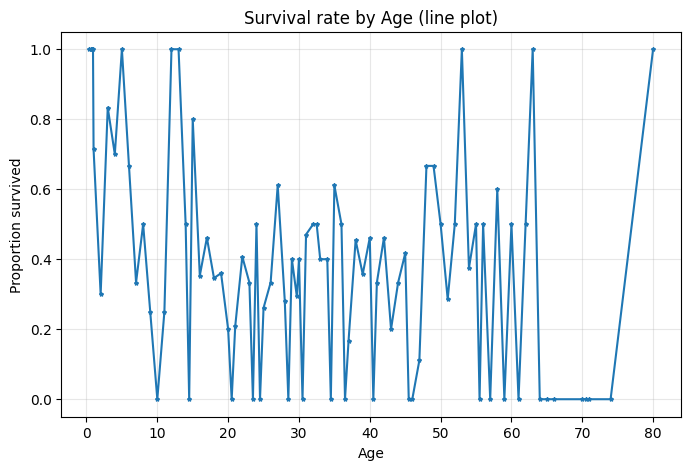

In [37]:
survival_by_age = df.groupby("Age")["Survived"].mean()
x = survival_by_age.index
y = survival_by_age.values

plt.figure(figsize=(8, 5))
plt.plot(x, y,
         marker = "*",
         markersize = 3)

plt.title("Survival rate by Age (line plot)")
plt.xlabel("Age")
plt.ylabel("Proportion survived")
plt.grid(True, alpha = 0.3)
plt.show()

*2. Bar Plot (Survival by Sex)*

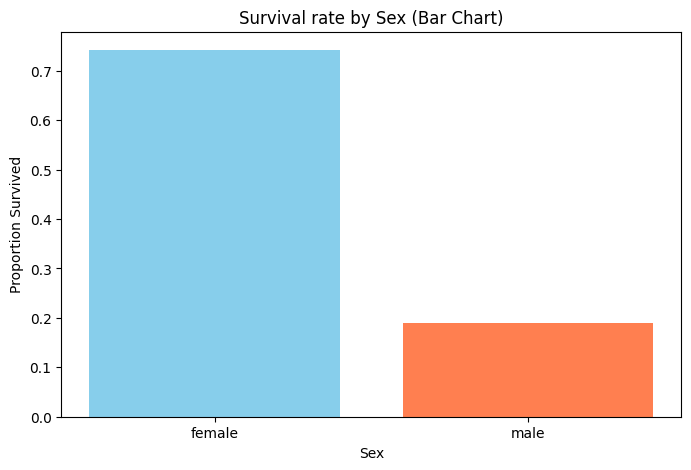

In [60]:
survival_by_sex = df.groupby("Sex")["Survived"].mean()
x = survival_by_sex.index
y = survival_by_sex.values

plt.figure(figsize=(8,5))
plt.title("Survival rate by Sex (Bar Chart)")
plt.bar(x, y, color = ["skyblue", "coral"])
plt.xlabel("Sex")
plt.ylabel("Proportion Survived")
# plt.xticks(rotation = 90)
plt.show()


*3. Pie Plot (Class distribution)*

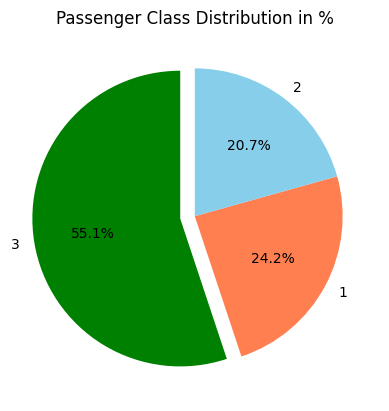

In [59]:
pClass_count = df["Pclass"].value_counts()
# pClass_count
labels = pClass_count.index
sizes = pClass_count.values

plt.Figure(figsize=(8,6))
explode = [0.1, 0, 0]
colors = ["green", "coral", "skyblue"]
plt.pie(sizes, 
        labels=labels,
        autopct="%1.1f%%",
        startangle=90,
        explode=explode,
        colors=colors)

plt.title("Passenger Class Distribution in %")
plt.show()

*4. Histogram (age distribution)*

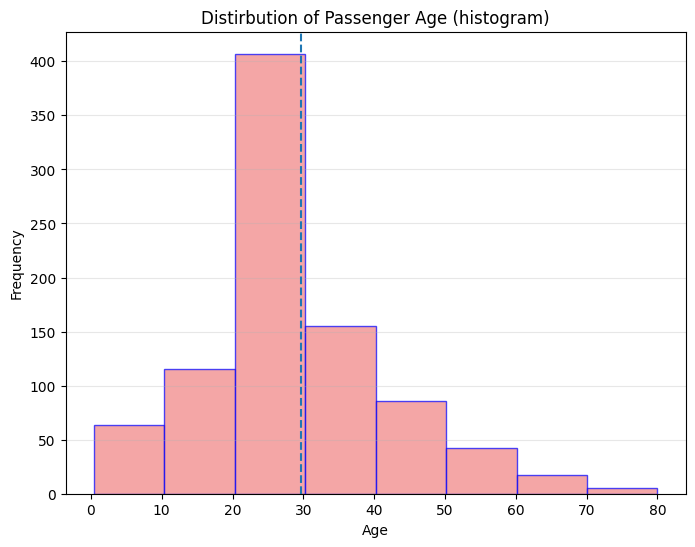

In [ ]:
mean_line = df["Age"].mean()

plt.figure(figsize=(8,6))
plt.hist(df["Age"],
         bins=8,
         color="lightcoral",
         edgecolor = "b",
         alpha = .7)

plt.title("Distirbution of Passenger Age (histogram)")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.grid(True, axis="y", alpha = .3)

plt.axvline(mean_line, linestyle = "--")
plt.show()

*5. Scatter Plot (Age vs Fare colored by Survival)*

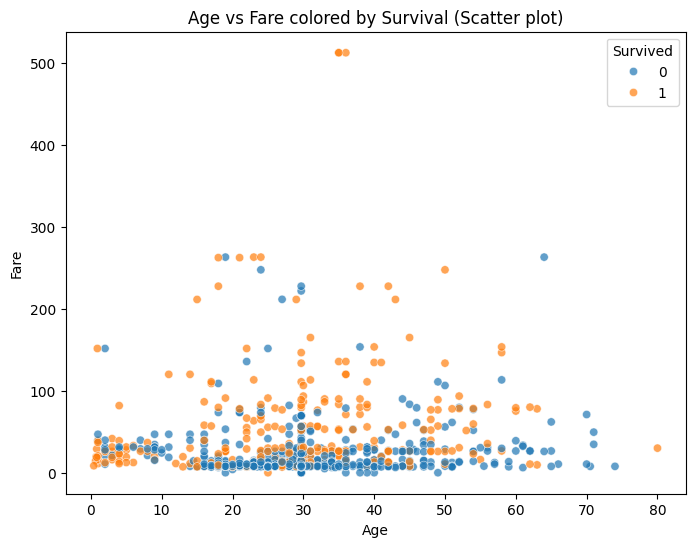

In [94]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data = df,
                x = "Age",
                y = "Fare",
                hue="Survived",
                alpha = .7)

plt.title("Age vs Fare colored by Survival (Scatter plot)")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

*6. Box Plot (Fare by passenger class)*

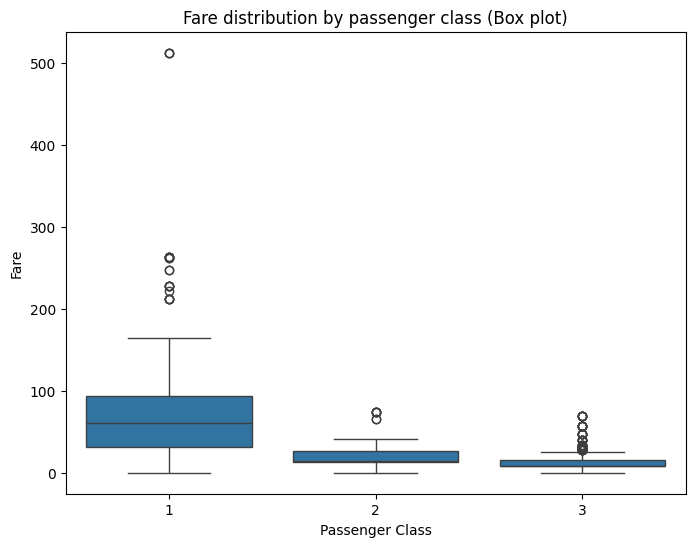

In [98]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, 
            x = "Pclass",
            y = "Fare")

plt.title("Fare distribution by passenger class (Box plot)")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.show()